GROUP DETAILS
Group Number (G): 121
Total Medicines (K): 6

Hidden Success Probabilities
Medicine 0 --> 0.47
Medicine 1 --> 0.54
Medicine 2 --> 0.61
Medicine 3 --> 0.68
Medicine 4 --> 0.75
Medicine 5 --> 0.4

First 10 Dataset Rows
   patient_id  severity_score
0           0               1
1           1               2
2           2               3
3           3               4
4           4               5
5           5               1
6           6               2
7           7               3
8           8               4
9           9               5

TASK 2 : IMMEDIATE EXPLOITATION

Best Medicine After Initial Testing: 4
Final Cumulative Reward: 516.5

TASK 3 : CONTROLLED CLINICAL TRIAL

Exploration = 10%
Cumulative Reward: 476.2

Exploration = 1%
Cumulative Reward: 474.3

Exploration = 50%
Cumulative Reward: 426.4

TASK 4 : UCB1
Final Cumulative Reward: 444.7

TASK 5 : COMPARATIVE ANALYSIS


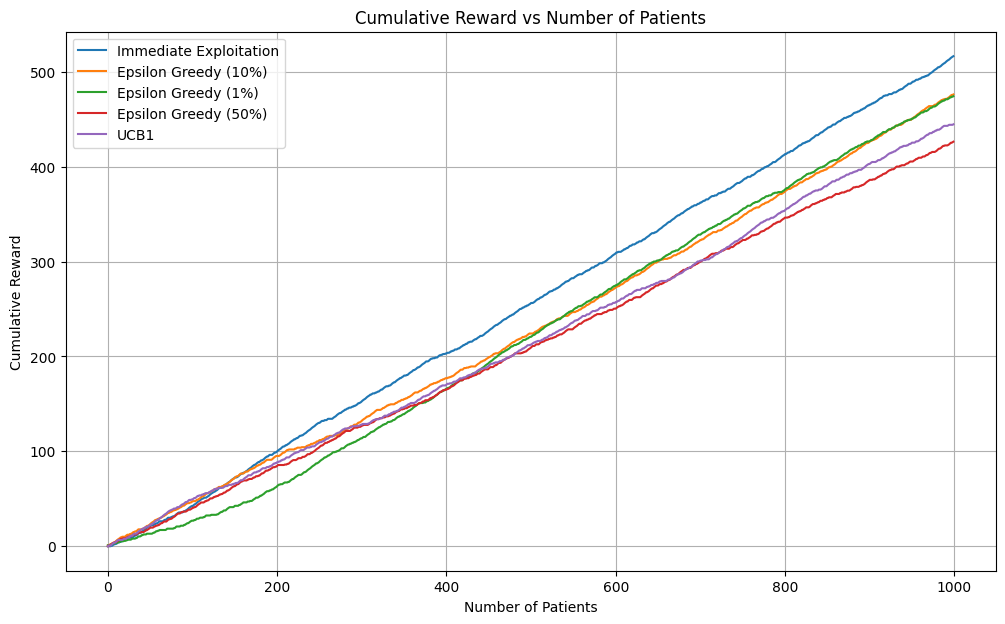


ANALYSIS

1. Immediate Exploitation:
   - Quickly locks onto one medicine.
   - Can perform poorly if early estimates are wrong.

2. Epsilon = 1%:
   - Very little exploration.
   - Faster exploitation.
   - Risk of getting stuck with suboptimal medicine.

3. Epsilon = 10%:
   - Balanced exploration and exploitation.
   - Usually performs best overall.

4. Epsilon = 50%:
   - Excessive exploration.
   - Too many random medicine selections.
   - Lower cumulative reward.

5. UCB1:
   - Automatically balances exploration.
   - Gives under-tested medicines more chances.
   - Often performs very efficiently.



In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# =========================================================
# TASK 1 : DATASET DESIGN
# =========================================================

# -----------------------------
# GROUP NUMBER
# -----------------------------

G = 121

# Reproducibility
random.seed(G)
np.random.seed(G)

# -----------------------------
# NUMBER OF MEDICINES
# -----------------------------

K = (G % 3) + 5

# -----------------------------
# HIDDEN SUCCESS PROBABILITIES
# -----------------------------

hidden_probabilities = []

for i in range(K):

    p_i = 0.4 + (((G + i) % 6) * 0.07)

    hidden_probabilities.append(round(p_i, 2))

# -----------------------------
# DISPLAY DETAILS
# -----------------------------

print("=" * 60)
print("GROUP DETAILS")
print("=" * 60)

print(f"Group Number (G): {G}")

print(f"Total Medicines (K): {K}")

print("\nHidden Success Probabilities")

for i, p in enumerate(hidden_probabilities):

    print(f"Medicine {i} --> {p}")

# -----------------------------
# CREATE DATASET
# -----------------------------

n_patients = 1000

patient_ids = np.arange(n_patients)

severity_scores = (patient_ids % 5) + 1

base_df = pd.DataFrame({
    "patient_id": patient_ids,
    "severity_score": severity_scores
})

print("\nFirst 10 Dataset Rows")

print(base_df.head(10))

# =========================================================
# COMMON FUNCTION
# =========================================================

def simulate_patient(medicine, severity):

    success_probability = hidden_probabilities[medicine]

    clinical_outcome = np.random.binomial(
        1,
        success_probability
    )

    utility_score = clinical_outcome * (1 - severity / 10)

    return clinical_outcome, utility_score

# =========================================================
# TASK 2 :
# IMMEDIATE EXPLOITATION STRATEGY
# =========================================================

print("\n" + "=" * 60)
print("TASK 2 : IMMEDIATE EXPLOITATION")
print("=" * 60)

Q = np.zeros(K)

N = np.zeros(K)

cumulative_reward = 0

reward_history_exploit = []

# -----------------------------------------
# INITIAL TESTING
# Each medicine exactly 10 times
# -----------------------------------------

patient_index = 0

for medicine in range(K):

    for _ in range(10):

        severity = base_df.loc[
            patient_index,
            "severity_score"
        ]

        outcome, reward = simulate_patient(
            medicine,
            severity
        )

        N[medicine] += 1

        Q[medicine] += (
            (outcome - Q[medicine]) / N[medicine]
        )

        cumulative_reward += reward

        reward_history_exploit.append(
            cumulative_reward
        )

        patient_index += 1

# -----------------------------------------
# SELECT CURRENT BEST MEDICINE
# -----------------------------------------

best_medicine = np.argmax(Q)

print(f"\nBest Medicine After Initial Testing: {best_medicine}")

# -----------------------------------------
# USE SAME MEDICINE FOREVER
# -----------------------------------------

while patient_index < n_patients:

    severity = base_df.loc[
        patient_index,
        "severity_score"
    ]

    outcome, reward = simulate_patient(
        best_medicine,
        severity
    )

    N[best_medicine] += 1

    Q[best_medicine] += (
        (outcome - Q[best_medicine])
        / N[best_medicine]
    )

    cumulative_reward += reward

    reward_history_exploit.append(
        cumulative_reward
    )

    patient_index += 1

print("Final Cumulative Reward:",
      round(cumulative_reward, 2))

# =========================================================
# TASK 3 :
# CONTROLLED CLINICAL TRIAL
# EPSILON GREEDY
# =========================================================

def epsilon_greedy(epsilon):

    Q = np.zeros(K)

    N = np.zeros(K)

    cumulative_reward = 0

    reward_history = []

    for patient in range(n_patients):

        # ---------------------------------
        # ACTION SELECTION
        # ---------------------------------

        if random.random() < epsilon:

            action = random.randint(0, K - 1)

        else:

            action = np.argmax(Q)

        # ---------------------------------
        # PATIENT RESPONSE
        # ---------------------------------

        severity = base_df.loc[
            patient,
            "severity_score"
        ]

        outcome, reward = simulate_patient(
            action,
            severity
        )

        # ---------------------------------
        # UPDATE STATISTICS
        # ---------------------------------

        N[action] += 1

        Q[action] += (
            (outcome - Q[action]) / N[action]
        )

        cumulative_reward += reward

        reward_history.append(cumulative_reward)

    return cumulative_reward, reward_history

print("\n" + "=" * 60)
print("TASK 3 : CONTROLLED CLINICAL TRIAL")
print("=" * 60)

# -----------------------------------------
# 10% EXPLORATION
# -----------------------------------------

reward_10, history_10 = epsilon_greedy(0.10)

print("\nExploration = 10%")
print("Cumulative Reward:",
      round(reward_10, 2))

# -----------------------------------------
# 1% EXPLORATION
# -----------------------------------------

reward_1, history_1 = epsilon_greedy(0.01)

print("\nExploration = 1%")
print("Cumulative Reward:",
      round(reward_1, 2))

# -----------------------------------------
# 50% EXPLORATION
# -----------------------------------------

reward_50, history_50 = epsilon_greedy(0.50)

print("\nExploration = 50%")
print("Cumulative Reward:",
      round(reward_50, 2))

# =========================================================
# TASK 4 :
# UCB1 ALGORITHM
# =========================================================

print("\n" + "=" * 60)
print("TASK 4 : UCB1")
print("=" * 60)

Q = np.zeros(K)

N = np.zeros(K)

cumulative_reward_ucb = 0

reward_history_ucb = []

# -----------------------------------------
# INITIALIZE:
# PLAY EACH ARM ONCE
# -----------------------------------------

for medicine in range(K):

    severity = base_df.loc[
        medicine,
        "severity_score"
    ]

    outcome, reward = simulate_patient(
        medicine,
        severity
    )

    N[medicine] += 1

    Q[medicine] = outcome

    cumulative_reward_ucb += reward

    reward_history_ucb.append(
        cumulative_reward_ucb
    )

# -----------------------------------------
# MAIN LOOP
# -----------------------------------------

for t in range(K, n_patients):

    ucb_values = np.zeros(K)

    for i in range(K):

        confidence = math.sqrt(
            (2 * math.log(t + 1))
            / N[i]
        )

        ucb_values[i] = Q[i] + confidence

    action = np.argmax(ucb_values)

    severity = base_df.loc[
        t,
        "severity_score"
    ]

    outcome, reward = simulate_patient(
        action,
        severity
    )

    N[action] += 1

    Q[action] += (
        (outcome - Q[action]) / N[action]
    )

    cumulative_reward_ucb += reward

    reward_history_ucb.append(
        cumulative_reward_ucb
    )

print("Final Cumulative Reward:",
      round(cumulative_reward_ucb, 2))

# =========================================================
# TASK 5 :
# COMPARATIVE ANALYSIS
# =========================================================

print("\n" + "=" * 60)
print("TASK 5 : COMPARATIVE ANALYSIS")
print("=" * 60)

plt.figure(figsize=(12, 7))

plt.plot(
    reward_history_exploit,
    label="Immediate Exploitation"
)

plt.plot(
    history_10,
    label="Epsilon Greedy (10%)"
)

plt.plot(
    history_1,
    label="Epsilon Greedy (1%)"
)

plt.plot(
    history_50,
    label="Epsilon Greedy (50%)"
)

plt.plot(
    reward_history_ucb,
    label="UCB1"
)

plt.xlabel("Number of Patients")

plt.ylabel("Cumulative Reward")

plt.title(
    "Cumulative Reward vs Number of Patients"
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# ANALYSIS
# =========================================================

print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)

print("""
1. Immediate Exploitation:
   - Quickly locks onto one medicine.
   - Can perform poorly if early estimates are wrong.

2. Epsilon = 1%:
   - Very little exploration.
   - Faster exploitation.
   - Risk of getting stuck with suboptimal medicine.

3. Epsilon = 10%:
   - Balanced exploration and exploitation.
   - Usually performs best overall.

4. Epsilon = 50%:
   - Excessive exploration.
   - Too many random medicine selections.
   - Lower cumulative reward.

5. UCB1:
   - Automatically balances exploration.
   - Gives under-tested medicines more chances.
   - Often performs very efficiently.
""")